# 02 - Integer Programming
---

### **Mixed Integer Linear Programming (MILP)**
Many real-world optimisation problems involve both continuous decisions (e.g. how much to produce) and discrete decisions (e.g. whether to build a factory or not). **Mixed-Integer Linear Programming (MILP)** is a mathematical framework designed to model such problems.

A MILP has:
- A linear objective function
- Linear constraints
- Some variables restricted to be integers

They can be expressed mathematically as:
$$
\begin{aligned}
\min \quad & c^T x \\
\text{subject to} \quad 
& Ax \le b \\
& x_i \in \mathbb{Z} \quad \text{for } i \in I \\
& x_j \in \mathbb{R} \quad \text{for } j \notin I
\end{aligned}
$$

where:
- $x$ is a vector of decision variables
- $c^T x$ is a linear objective function
- $Ax \le b$ represents a set of linear constraints
- Some variables are restricted to be integers
- The remaining variables are continuous

Often integer variables are binary $x_i \in \{0, 1\}$ which is very powerful for modelling logical decisions. For instance they can be used in scheduling to decide if a certain task is scheduled at a particular time or not.

### **Presolving**
Before attempting to some a MILP, many solver algorithms will apply **presolving** techniques. These simplify the constraints to make the problem simpler and therefore faster to solve. Some examples of how constraints can be simplified during presolving are listed below:
- Remove redundant constraints: $$x \le 5 \; \& \; x \le 10 \Rightarrow x \le 5$$
- Tighten variables with constraints: $$4x + 6y < 10 \; \& \; y \ge 1 \Rightarrow 4x + 6(1) < 10 \Rightarrow x \le 1$$
- Fix variables when implied by bounds $$x >= 1 \; \& \; x \in \{0,1\} \Rightarrow x = 1$$
- Substitute variables using equalities (either direct or implied) $$x + y =5 \; \& \; y = 2 \Rightarrow x = 3$$

### **Linear Relaxation**
Generally the integer constraints make the problem extremely computationally expensive to solve so many modern solvers use a combination of advanced strategies to attempt to find an optimal solution. One key idea is **linear relaxation** which is where the integer constraints are temporarily ignored so as to simplify the problem down to a standard **Linear Programme (LP)** which is solvable in polynomial time. Further techniques are then applied to build on the solution found with the integer constraints relaxed and turn it into a solution which adheres to the linear constraints. 

For example, we may be working on a scheduling problem where we have binary decision variables $x_i \in \{0, 1\}$ each representing whether a particular task is scheduled in at a particular time or not. Linear relaxation would involved temporarily modifying this constraint to be $x_i \in [0, 1]$, and solving the resulting LP. We could then apply the techniques discussed below to turn this solution into a solution which complies with the integer constraint initially set. 

### **Branch-and-Bound (B&B)**
Terminology: A solution to a linearly relaxed MLIP problem is said to be **integer** if all variables with an integer constraint in the unrelaxed problem are assigned integer values. Otherwise it is **non-integer/fractional** meaning there exists some variable which has an integer constraint in the unrelaxed problem but which has been assigned a non-integer value in the solution thus making the solution infeasible.  

**Branch-and-Bound (B&B)** is a technique for solving MILP which works as follows:
1. Initialise the incumbent which is the current best solution. Initially this will be empty
2. Relax the integer constraints and solve the simplified problem (e.g. via simplex)
3. Do the following based on the solution:
    - If the solution is integer and better than the incumbent, update the incumbent
    - If the solution is integer but worse than the incumbent prune (discard) it 
    - If the solution is non-integer, apply branching 
4. Choose a variable $x$ which violates the integer constraint and create two sub-problems:
    - $x \le \lfloor(x)\rfloor$ (e.g. $x = 3.7 \Rightarrow x \le 3$)
    - $x \ge \lceil(x)\rceil$ (e.g. $x = 3.7 \Rightarrow x \ge 4$)
4. Repeat steps 2-4 on each of the sub-problems. Stop once all nodes have been explored or pruned; at this point the incumbent is globally optimal

The beauty of this approach is that rather than needing to run through exponentially many integer combinations, we can rule out large chunks of the search space at once. LP relaxation creates optimisic bounds, hence if a region cannot possibly improve the best known integer solution, we safely discard it.


### **Cutting Planes: Branch-and-Cut (B&C)**
Branch and bound is a powerful technique for solving MILP problems however it does require looping through many nodes, relaxing the integer constraints and solving which can still be time consuming if there are many nodes. **Branch-and-cut (B&C)** is a technique run before B&B which works to simplify the number of nodes that require checking. It works by constructing a new linear constraint that removes the current fractional solution but keeps all feasible integer solutions. It restricts the search space for the relaxed LP without removing the real optimal solution meaning many non-integer solutions disappear early, shrinking the tree which makes the problem faster to solve. 

Consider the following example:

$$
\max \; z = x + y
$$

Subject to:

$$
2x + y \le 4
$$

$$
x + 2y \le 4
$$

$$
x, y \ge 0
$$

$$
x, y \in \mathbb{Z}
$$

If we relax the integer constraints, the LP solution is:

$$
x = \frac{4}{3}, \quad y = \frac{4}{3}
$$

with objective value:

$$
z = \frac{8}{3}
$$

This solution is fractional and therefore infeasible for the integer program.


To derive a cut, add the two original constraints:

$$
(2x + y) + (x + 2y) \le 4 + 4
$$

$$
3x + 3y \le 8
$$

Divide by 3:

$$
x + y \le \frac{8}{3}
$$

Since $x$ and $y$ are integers, $x + y$ must also be an integer.

Because

$$
x + y \le \frac{8}{3} \approx 2.67
$$

the largest possible integer value is:

$$
x + y \le 2
$$

This inequality is the cut. 

The fractional LP solution:

$$
\frac{4}{3} + \frac{4}{3} = \frac{8}{3}
$$

violates:

$$
x + y \le 2
$$

so it is removed.

However, all feasible integer solutions such as:

$$
(1,1), \quad (2,0), \quad (0,2)
$$

satisfy:

$$
x + y \le 2
$$

Thus, the cut removes the fractional solution but keeps all valid integer solutions.

Conceptually, a cutting plane is a valid inequality that eliminates fractional LP solutions without excluding any feasible integer solutions.

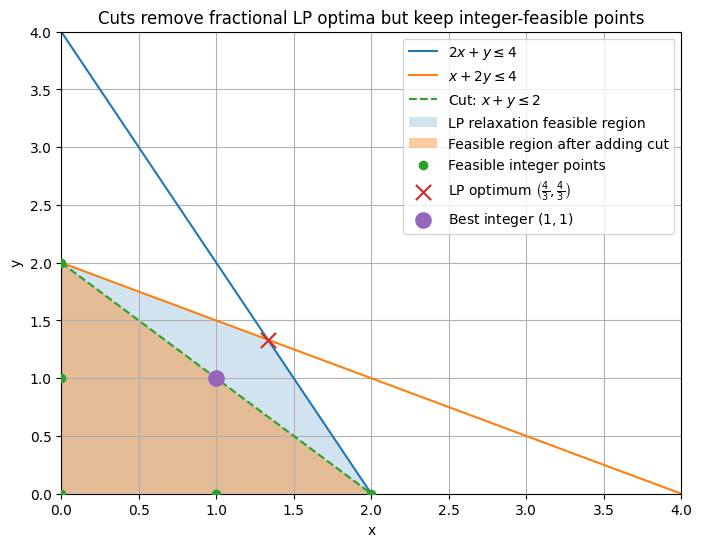

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constraints:
# 2x + y <= 4  -> y <= 4 - 2x
# x + 2y <= 4  -> y <= (4 - x)/2
# x >= 0, y >= 0
# Cut:
# x + y <= 2   -> y <= 2 - x

x = np.linspace(0, 4, 400)
y1 = 4 - 2*x
y2 = (4 - x)/2
ycut = 2 - x

# LP feasible upper envelope
y_lp = np.minimum(y1, y2)
y_lp = np.maximum(y_lp, 0)

# With cut
y_with_cut = np.minimum(y_lp, ycut)
y_with_cut = np.maximum(y_with_cut, 0)

# Integer feasible points (small bounding box)
int_points = []
for xi in range(0, 5):
    for yi in range(0, 5):
        if 2*xi + yi <= 4 and xi + 2*yi <= 4:
            int_points.append((xi, yi))
int_points = np.array(int_points)

lp_opt = (4/3, 4/3)
best_int = (1, 1)

plt.figure(figsize=(8, 6))

# Constraint lines
plt.plot(x, y1, label=r"$2x + y \leq 4$")
plt.plot(x, y2, label=r"$x + 2y \leq 4$")
plt.plot(x, ycut, "--", label=r"Cut: $x + y \leq 2$")

# Shade feasible regions
plt.fill_between(x, 0, y_lp, alpha=0.2, label="LP relaxation feasible region")
plt.fill_between(x, 0, y_with_cut, alpha=0.4, label="Feasible region after adding cut")

# Integer points
plt.scatter(int_points[:, 0], int_points[:, 1], zorder=5, label="Feasible integer points")

# Mark optima
plt.scatter(*lp_opt, marker="x", s=120, zorder=6, label=r"LP optimum $\left(\frac{4}{3},\frac{4}{3}\right)$")
plt.scatter(*best_int, marker="o", s=120, zorder=6, label=r"Best integer $(1,1)$")

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cuts remove fractional LP optima but keep integer-feasible points")
plt.grid(True)
plt.legend()
plt.show()

### **Primal Heuristics**
Primal heuristics are procedures that attempt to construct feasible integer solutions during the B&B search. Their purpose is to improve the incumbent solution early, thereby strengthening the global bound and enabling more aggressive pruning of the search tree.

SCIP includes multiple classes of heuristics:
- Rounding heuristics (derive integer solutions from LP relaxations)
- Diving heuristics (simulate branching locally)
- Feasibility pump (alternate between LP and integer rounding)
- RINS and large neighborhood search (explore neighborhoods of good solutions)
- Local branching (restrict search to solutions near the incumbent)

Heuristics do not guarantee optimality; instead, they accelerate solving by tightening bounds. In practice, the interaction between heuristics, cutting planes, and branching is what makes SCIP highly effective.

The example below demonstrates the rounding heuristic. The basic idea here is to round non-integer variables from LP solutions to nearby integer values, resolve with LP relaxation and check if the solution is feasible and more optimal than the incumbent

Consider the integer program:

$$
\max \; z = 3x + 2y
$$

Subject to:

$$
2x + y \le 4
$$

$$
x + y \le 3
$$

$$
x, y \ge 0
$$

$$
x, y \in \mathbb{Z}
$$


First, ignore the integer constraints, suppose this LP relaxation gives the solution:

$$
x = 1.5, \quad y = 1
$$

Objective value:

$$
z = 3(1.5) + 2(1) = 6.5
$$

This solution is fractional and therefore infeasible for the integer problem.

Round $x$ up to the nearest integer:

$$
x = 2
$$

Keep $y = 1$.

Check feasibility:

$$
2(2) + 1 = 5 \nleq 4
$$

This violates the first constraint, so rounding up is infeasible.

Instead round $x$ down:

$$
x = 1, \quad y = 1
$$

Check feasibility:

$$
2(1) + 1 = 3 \le 4
$$

$$
1 + 1 = 2 \le 3
$$

This solution is feasible.

The rounded feasible solution is:

$$
(x,y) = (1,1)
$$

with objective value:

$$
z = 3(1) + 2(1) = 5
$$


A rounding heuristic:
- Starts from the fractional LP solution
- Rounds variables up or down
- Keeps the rounded solution only if it remains feasible

It is fast and simple, and although it does not guarantee optimality, it often produces good feasible integer solutions early in the search.

### **SCIP**
**SCIP** is a solver used to optimise MILP problems. It combines multiple techniques and strategies to find the optimal solution efficiently. 

The steps taken by SCIP are as follows:
- **Presolving**: Simplifies the model before search by tightening bounds, fixing variables, removing redundancies, and detecting infeasibility
- **Root LP Solve**: Solves the LP relaxation of the simplified problem to obtain an initial bound and fractional solution
- **Cutting Planes (Branch-and-Cut)**: Adds valid inequalities that remove fractional LP solutions while preserving all integer-feasible solutions, tightening the relaxation
- **Propagation**: Tightens variable domains after branching or cuts; may detect infeasibility early and prune nodes without solving an LP
- **Primal Heuristics**: Attempts to construct feasible integer solutions during the search to improve the incumbent and strengthen pruning
- **Branch-and-Bound**: Branches on fractional variables to create subproblems and systematically explores the search tree, pruning using bounds
- **Conflict Analysis (Learning)**: When infeasibility is detected, derives constraints that prevent similar conflicts elsewhere in the tree